In [2]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

import keras

In [3]:
titanic3 = pandas.read_csv("../conjuntos/titanic3.csv")
titanic3

,Sex,Age,Pclass2,Family,Family2,Fare2,Cabin2,Embarked2,Survived2
0,male,22.0,3ra,1,couple,2.110213,no,S,no
1,female,38.0,1ra,1,couple,4.280593,yes,C,yes
2,female,26.0,3ra,0,single,2.188856,no,S,yes
3,female,35.0,1ra,1,couple,3.990834,yes,S,yes
4,male,35.0,3ra,0,single,2.202765,no,S,no
...,...,...,...,...,...,...,...,...,...
886,male,27.0,2da,0,single,2.639057,no,S,no
887,female,19.0,1ra,0,single,3.433987,yes,S,yes
888,female,NaN,3ra,3,family,3.196630,no,S,no
889,male,26.0,1ra,0,single,3.433987,yes,C,yes


## Sobrevive vs Sexo (Categórico vs Categórico)

> Mapa de calor / Matriz de densidad (conteos)

In [26]:
R1 = titanic3[["Survived2", "Sex"]].groupby(["Survived2", "Sex"]).size().unstack()
R1

Sex,female,male
Survived2,,
no,81,468
yes,233,109


In [12]:
R2 = R1.divide(R1.sum(axis=0), axis=1).round(2)
R2

Sex,female,male
Survived2,,
no,0.26,0.81
yes,0.74,0.19


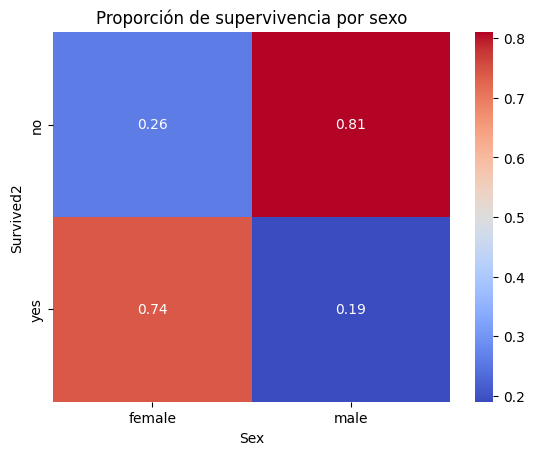

In [19]:
seaborn.heatmap(R2, cmap="coolwarm", annot=True)
pyplot.title("Proporción de supervivencia por sexo")
pyplot.show()

In [20]:
R3 = R1.divide(R1.sum(axis=1), axis=0).round(2).T
R3

Survived2,no,yes
Sex,,
female,0.15,0.68
male,0.85,0.32


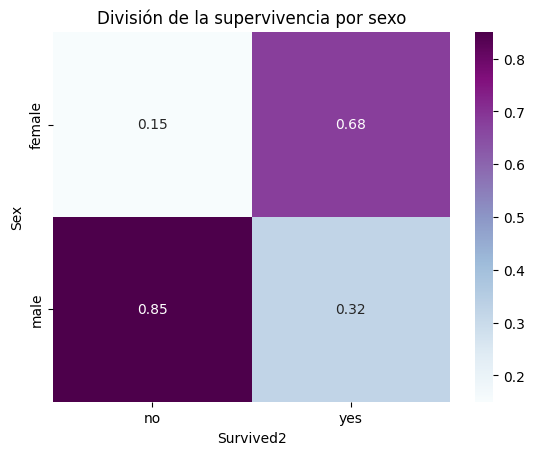

In [24]:
seaborn.heatmap(R3, cmap="BuPu", annot=True)
pyplot.title("División de la supervivencia por sexo")
pyplot.show()

## Supervivencia vs Edad (Categórico vs Numérico)

> Densidad separada (por categoría)
> 
> Cajas separadas (por categoría)

<Axes: xlabel='Age', ylabel='Density'>

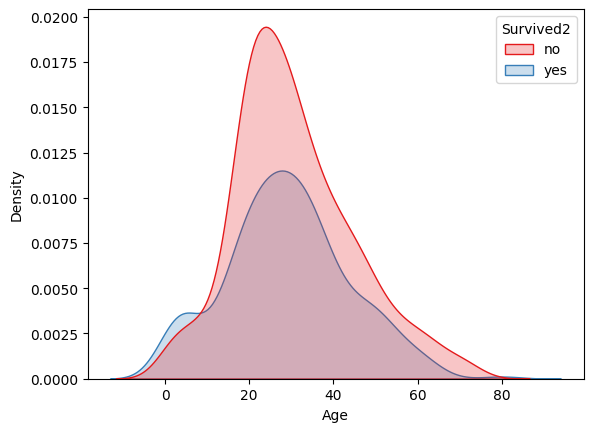

In [29]:
seaborn.kdeplot(x=titanic3["Age"], hue=titanic3["Survived2"], fill=True, palette="Set1")

<Axes: xlabel='Survived2', ylabel='Age'>

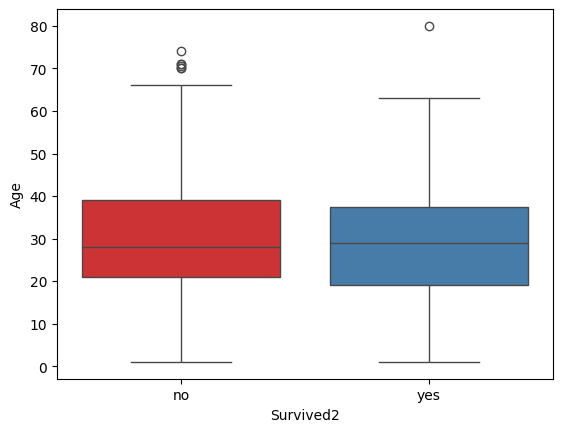

In [ ]:
seaborn.boxplot(x=titanic3["Survived2"], y=titanic3["Age"], hue=titanic3["Survived2"], palette="Set1")

In [38]:
c1 = titanic3["Sex"] + "-" + titanic3["Survived2"]
c1

0         male-no
1      female-yes
2      female-yes
3      female-yes
4         male-no
          ...    
886       male-no
887    female-yes
888     female-no
889      male-yes
890       male-no
Length: 891, dtype: object

<Axes: xlabel='Age', ylabel='Density'>

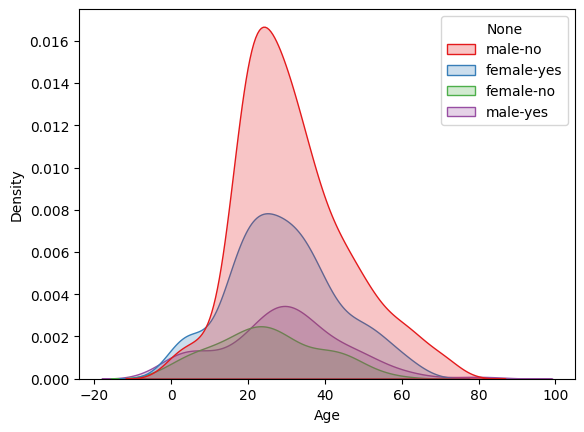

In [40]:
seaborn.kdeplot(x=titanic3["Age"], hue=c1, fill=True, palette="Set1")

<Axes: xlabel='None', ylabel='Age'>

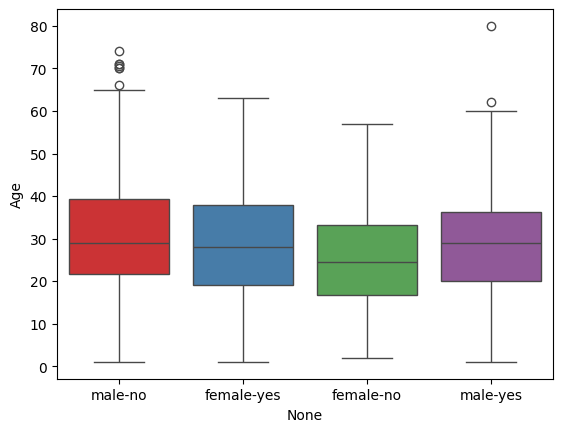

In [41]:
seaborn.boxplot(x=c1, y=titanic3["Age"], hue=c1, palette="Set1")